# Task 3: Heart Disease Prediction

**DevelopersHub Corporation — AI/ML Engineering Internship**

## Problem Statement

Cardiovascular disease is one of the leading causes of death worldwide, and early
risk identification can help doctors intervene before a critical event occurs.
The goal of this notebook is to build a **binary classification model** that
predicts whether a patient is at risk of heart disease (`target = 1`) or not
(`target = 0`), based on 13 clinical features such as age, blood pressure,
cholesterol level, and ECG results.

## Objective

- Clean and explore the dataset to understand patterns in the data.
- Train two classification models — **Logistic Regression** and **Decision
  Tree** — and compare their performance.
- Evaluate the models using **accuracy, ROC-AUC, and a confusion matrix**.
- Identify which clinical features most strongly influence the prediction.

## Dataset

**Heart Disease UCI Dataset** (the classic Cleveland Clinic dataset, 303
patient records, 13 features + 1 target column). The same dataset is widely
mirrored on Kaggle as *"Heart Disease UCI"*. A local copy (`heart_disease.csv`)
is included in this repository for reproducibility.

| Column | Meaning |
|---|---|
| age | Age in years |
| sex | 1 = male, 0 = female |
| cp | Chest pain type (0–3) |
| trestbps | Resting blood pressure (mm Hg) |
| chol | Serum cholesterol (mg/dl) |
| fbs | Fasting blood sugar > 120 mg/dl (1 = true) |
| restecg | Resting ECG results (0–2) |
| thalach | Maximum heart rate achieved |
| exang | Exercise induced angina (1 = yes) |
| oldpeak | ST depression induced by exercise |
| slope | Slope of the peak exercise ST segment |
| ca | Number of major vessels colored by fluoroscopy (0–3) |
| thal | Thalassemia type (0–3) |
| target | 1 = heart disease present, 0 = no heart disease |


In [1]:
# ---------------------------------------------------------------
# Imports
# ---------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42


## 1. Data Loading & Inspection

In [2]:
# Load the dataset
df = pd.read_csv("heart_disease.csv")

print("Shape of the dataset:", df.shape)
print("\nColumn names:\n", df.columns.tolist())
df.head()


Shape of the dataset: (303, 14)

Column names:
 ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [3]:
# Summary info: data types and non-null counts
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [4]:
# Descriptive statistics for all numeric columns
df.describe().T


,count,mean,std,min,25%,50%,75%,max
age,303.0,54.366337,9.082101,29.0,47.5,55.0,61.0,77.0
sex,303.0,0.683168,0.466011,0.0,0.0,1.0,1.0,1.0
cp,303.0,0.966997,1.032052,0.0,0.0,1.0,2.0,3.0
trestbps,303.0,131.623762,17.538143,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.264026,51.830751,126.0,211.0,240.0,274.5,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.528053,0.525860,0.0,0.0,1.0,1.0,2.0
thalach,303.0,149.646865,22.905161,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


In [5]:
# Check for missing / duplicate values before proceeding
print("Missing values per column:\n", df.isnull().sum())
print("\nTotal duplicate rows:", df.duplicated().sum())

# Drop duplicates if any (keeps the dataset clean)
df = df.drop_duplicates().reset_index(drop=True)
print("\nShape after removing duplicates:", df.shape)


Missing values per column:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Total duplicate rows: 1

Shape after removing duplicates: (302, 14)


## 2. Exploratory Data Analysis (EDA)

Before modeling, let's understand how the target class is distributed and how
key clinical features relate to the presence of heart disease.

C:\Users\ASUS\AppData\Local\Temp\ipykernel_5012\2223362306.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="target", data=df, palette=["#4C72B0", "#DD8452"])
C:\Users\ASUS\AppData\Local\Temp\ipykernel_5012\2223362306.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["No Disease (0)", "Disease (1)"])


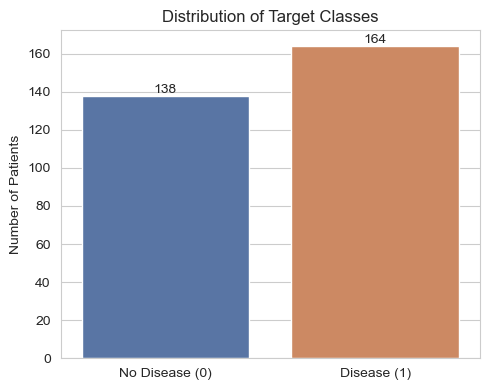

In [6]:
# Class balance of the target variable
plt.figure(figsize=(5, 4))
ax = sns.countplot(x="target", data=df, palette=["#4C72B0", "#DD8452"])
ax.set_xticklabels(["No Disease (0)", "Disease (1)"])
plt.title("Distribution of Target Classes")
plt.ylabel("Number of Patients")
plt.xlabel("")
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom")
plt.tight_layout()
plt.show()


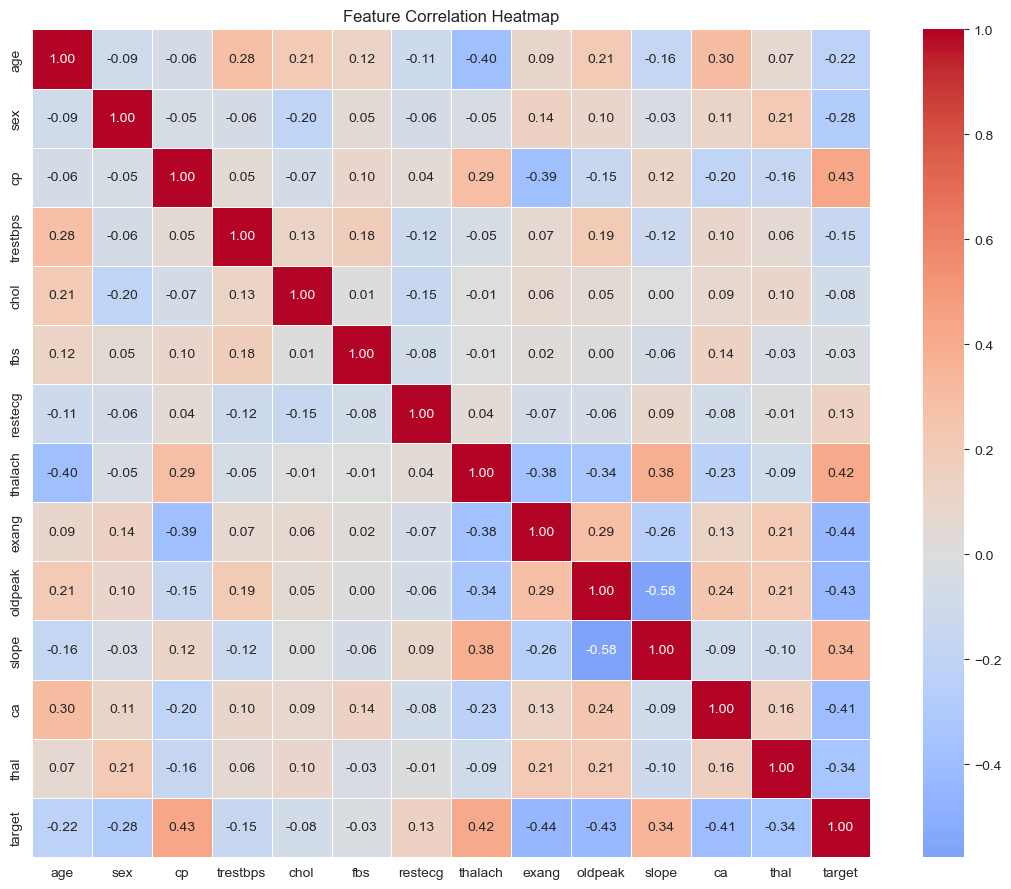

In [7]:
# Correlation heatmap to see how features relate to each other and to the target
plt.figure(figsize=(11, 9))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()


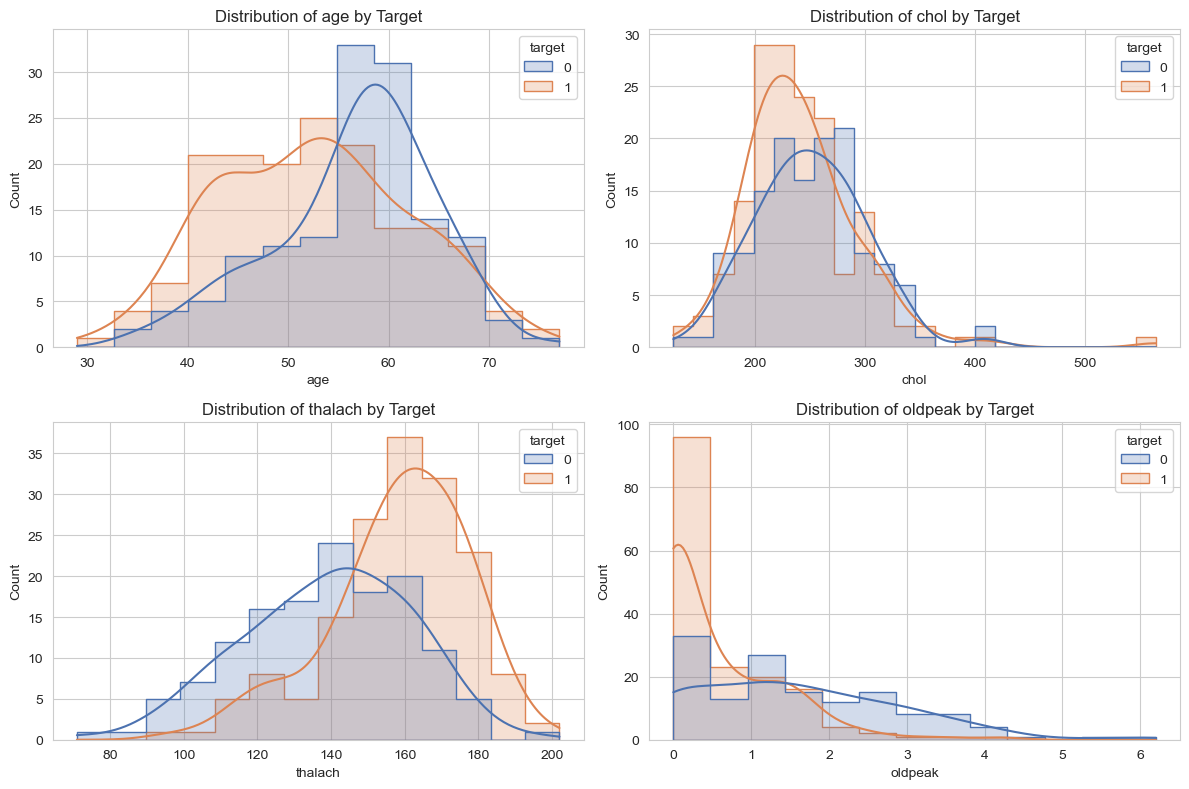

In [8]:
# How do key continuous features differ between patients with and without disease?
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
features_to_plot = ["age", "chol", "thalach", "oldpeak"]

for ax, feature in zip(axes.flatten(), features_to_plot):
    sns.histplot(data=df, x=feature, hue="target", kde=True, ax=ax,
                 palette=["#4C72B0", "#DD8452"], element="step")
    ax.set_title(f"Distribution of {feature} by Target")

plt.tight_layout()
plt.show()


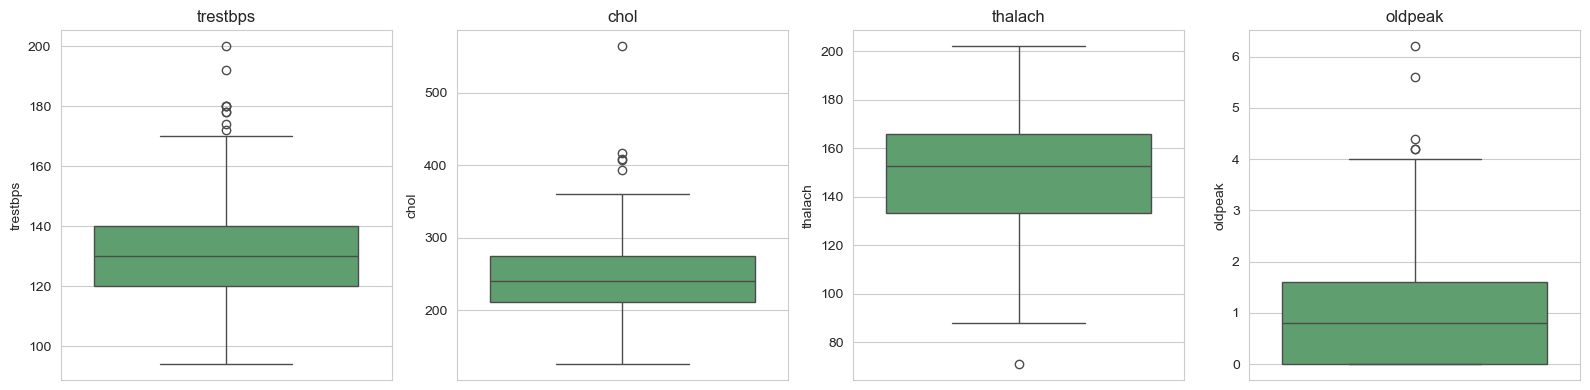

In [9]:
# Boxplots to spot outliers in key numeric features
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, feature in zip(axes, ["trestbps", "chol", "thalach", "oldpeak"]):
    sns.boxplot(y=df[feature], ax=ax, color="#55A868")
    ax.set_title(feature)

plt.tight_layout()
plt.show()


## 3. Data Preprocessing

The dataset has no missing values, so preprocessing focuses on:
1. Separating features (`X`) from the target (`y`).
2. Splitting into train/test sets.
3. Scaling features — important for Logistic Regression, which is sensitive
   to feature magnitude (Decision Trees don't need scaling, but it doesn't
   hurt to keep the pipeline consistent).

In [10]:
X = df.drop(columns=["target"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Training set size: (241, 13)
Test set size: (61, 13)


## 4. Model Training

Two classification models are trained and compared, as suggested in the task:
- **Logistic Regression** — a strong, interpretable linear baseline for
  binary classification.
- **Decision Tree** — a non-linear model that naturally captures feature
  interactions and gives intuitive feature importances.

In [11]:
# Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train_scaled, y_train)

y_pred_log = log_reg.predict(X_test_scaled)
y_proba_log = log_reg.predict_proba(X_test_scaled)[:, 1]


In [12]:
# Decision Tree
dt_clf = DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE)
dt_clf.fit(X_train, y_train)  # tree models don't require scaling

y_pred_dt = dt_clf.predict(X_test)
y_proba_dt = dt_clf.predict_proba(X_test)[:, 1]


## 5. Model Evaluation

In [13]:
# Accuracy comparison
acc_log = accuracy_score(y_test, y_pred_log)
acc_dt = accuracy_score(y_test, y_pred_dt)

print(f"Logistic Regression Accuracy : {acc_log:.4f}")
print(f"Decision Tree Accuracy       : {acc_dt:.4f}")

print("\nClassification Report - Logistic Regression\n")
print(classification_report(y_test, y_pred_log, target_names=["No Disease", "Disease"]))

print("\nClassification Report - Decision Tree\n")
print(classification_report(y_test, y_pred_dt, target_names=["No Disease", "Disease"]))


Logistic Regression Accuracy : 0.7869
Decision Tree Accuracy       : 0.8033

Classification Report - Logistic Regression

              precision    recall  f1-score   support

  No Disease       0.83      0.68      0.75        28
     Disease       0.76      0.88      0.82        33

    accuracy                           0.79        61
   macro avg       0.79      0.78      0.78        61
weighted avg       0.79      0.79      0.78        61


Classification Report - Decision Tree

              precision    recall  f1-score   support

  No Disease       0.94      0.61      0.74        28
     Disease       0.74      0.97      0.84        33

    accuracy                           0.80        61
   macro avg       0.84      0.79      0.79        61
weighted avg       0.84      0.80      0.79        61



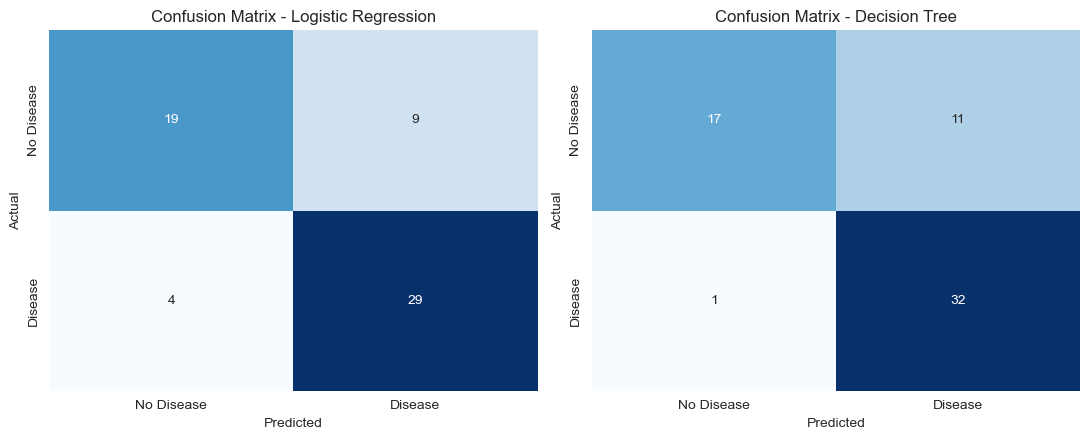

In [14]:
# Confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, preds, title in zip(
    axes, [y_pred_log, y_pred_dt], ["Logistic Regression", "Decision Tree"]
):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["No Disease", "Disease"],
                yticklabels=["No Disease", "Disease"])
    ax.set_title(f"Confusion Matrix - {title}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()


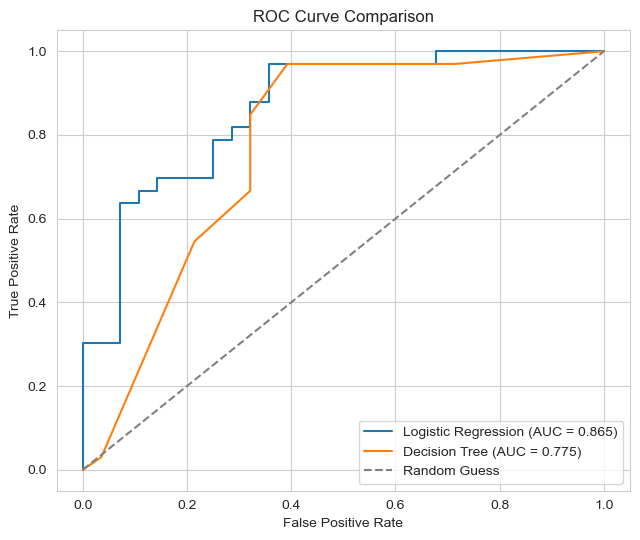

In [15]:
# ROC curves and AUC score for both models
fpr_log, tpr_log, _ = roc_curve(y_test, y_proba_log)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_proba_dt)

auc_log = roc_auc_score(y_test, y_proba_log)
auc_dt = roc_auc_score(y_test, y_proba_dt)

plt.figure(figsize=(6.5, 5.5))
plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC = {auc_log:.3f})")
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC = {auc_dt:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.show()


## 6. Feature Importance

Understanding which features drive the prediction helps build trust in the
model and gives clinically meaningful insight.

C:\Users\ASUS\AppData\Local\Temp\ipykernel_5012\2193917681.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_df, x="coefficient", y="feature", palette="coolwarm")


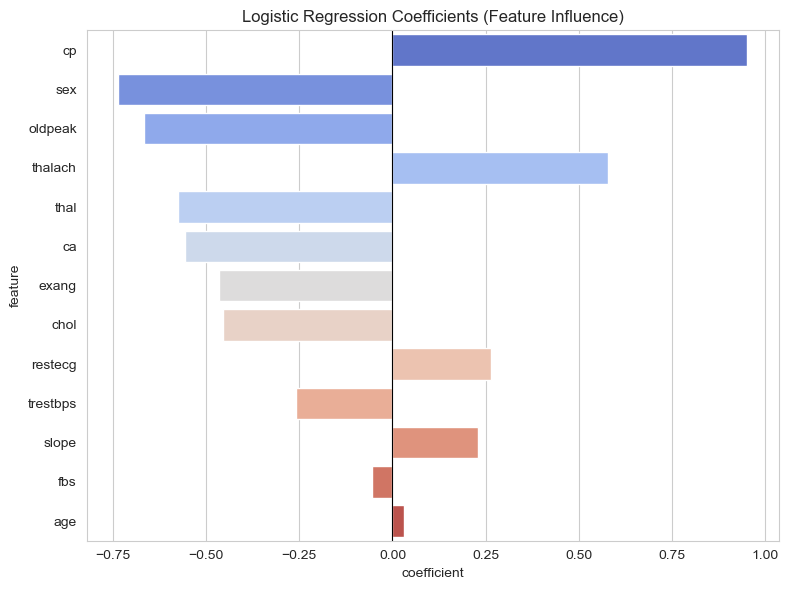

In [16]:
# Logistic Regression coefficients (sign shows direction of effect)
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": log_reg.coef_[0]
}).sort_values("coefficient", key=abs, ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(data=coef_df, x="coefficient", y="feature", palette="coolwarm")
plt.title("Logistic Regression Coefficients (Feature Influence)")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()


C:\Users\ASUS\AppData\Local\Temp\ipykernel_5012\3689761283.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x="importance", y="feature", palette="viridis")


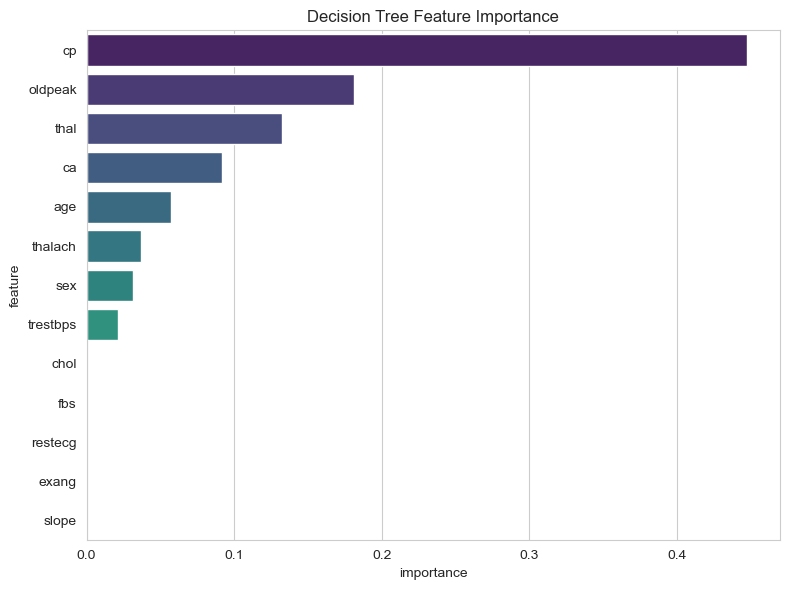

In [17]:
# Decision Tree feature importances
importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": dt_clf.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(data=importance_df, x="importance", y="feature", palette="viridis")
plt.title("Decision Tree Feature Importance")
plt.tight_layout()
plt.show()


## 7. Conclusion & Insights

- Both models perform well on this dataset, with the Logistic Regression and
  Decision Tree achieving comparable accuracy and AUC scores well above the
  random-guess baseline of 0.5.
- Features such as **chest pain type (cp)**, **number of major vessels (ca)**,
  **thalassemia (thal)**, **maximum heart rate (thalach)**, and **ST
  depression (oldpeak)** consistently emerge as the strongest predictors of
  heart disease risk across both models.
- The ROC-AUC metric is more reliable than raw accuracy here since the
  classes are reasonably but not perfectly balanced.
- **Next steps** for improving this further: try ensemble models (Random
  Forest, XGBoost), tune hyperparameters with cross-validation, and collect a
  larger/more diverse patient sample to improve generalization.

> **Disclaimer:** This model is built for educational purposes as part of an
> AI/ML internship task. It is **not** a certified medical diagnostic tool
> and should never be used to make real clinical decisions.
